# Optimal Penalty for `LogisticRegression`

## Code for Benchmarks
Some code borrowed from https://github.com/thomasjpfan/sk_encoder_cv.

In [ ]:
# %load_ext lab_black

In [1]:
import warnings
from dataclasses import dataclass
from time import perf_counter

import numpy as np
import polars as pl
import polars.selectors as cs
import scipy
import scipy.sparse as sp
from sklearn.compose import ColumnTransformer
from sklearn.datasets import fetch_openml
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegressionCV
from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.preprocessing import OneHotEncoder, SplineTransformer


@dataclass
class DataInfo:
    data_name: str
    data_id: int
    tab_arena: bool = False
    columns_to_remove: list[str] | None = None
    n_jobs: int | None = None

# datasets with the longest fit time:
# 1. ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014 890s
# 2. Higgs-LeoGrin 760s
# 3. sf-police-incidents 280s
# 4. APSFailure 220s
# 5. porto_seguro 200s
# 6. Bioresponse 200s

DATA_INFOS = {
    # START Tab-Arena, see https://arxiv.org/html/2506.16791v4#A2.T2
    # only classification datasets
    "blood-transfusion-service-center": DataInfo(
        data_name="blood-transfusion-service-center", data_id=46913, tab_arena=True
    ),
    "diabetes": DataInfo(data_name="diabetes", data_id=46921, tab_arena=True),  # altenative ID=37
    "anneal": DataInfo(data_name="anneal", data_id=46906, tab_arena=True),
    "credit-g": DataInfo(data_name="credit-g", data_id=46918, tab_arena=True),  # alternative ID=31
    "maternal_health_risk": DataInfo(data_name="maternal_health_risk", data_id=46941, tab_arena=True),
    "qsar-biodeg": DataInfo(data_name="qsar-biodeg", data_id=46952, tab_arena=True),
    "website_phishing": DataInfo(data_name="website_phishing", data_id=46963, tab_arena=True),
    "Fitness_Club": DataInfo(data_name="Fitness_Club", data_id=46927, tab_arena=True),
    "MIC": DataInfo(data_name="MIC", data_id=46980, tab_arena=True),
    "Is-this-a-good-customer": DataInfo(data_name="Is-this-a-good-customer", data_id=46938, tab_arena=True),
    "Marketing_Campaign": DataInfo(data_name="Marketing_Campaign", data_id=46940, tab_arena=True),
    "hazelnut-spread-contaminant-detection": DataInfo(
        data_name="hazelnut-spread-contaminant-detection", data_id=46930, tab_arena=True
    ),
    "seismic-bumps": DataInfo(data_name="seismic-bumps", data_id=46956, tab_arena=True),
    "splice": DataInfo(data_name="splice", data_id=46958, tab_arena=True),
    "Bioresponse": DataInfo(data_name="Bioresponse", data_id=46912, tab_arena=True),
    "hiva_agnostic": DataInfo(data_name="hiva_agnostic", data_id=46933, tab_arena=True),
    "students_dropout_and_academic_success": DataInfo(
        data_name="students_dropout_and_academic_success", data_id=46960, tab_arena=True
    ),
    "churn": DataInfo(data_name="churn", data_id=46915, tab_arena=True),  # altenative ID=40701
    "polish_companies_bankruptcy": DataInfo(
        data_name="polish_companies_bankruptcy", data_id=46950, tab_arena=True
    ),
    "taiwanese_bankruptcy_prediction": DataInfo(
        data_name="taiwanese_bankruptcy_prediction", data_id=46962, tab_arena=True
    ),
    "NATICUSdroid": DataInfo(data_name="NATICUSdroid", data_id=46969, tab_arena=True),
    "coil2000_insurance_policies": DataInfo(
        data_name="coil2000_insurance_policies", data_id=46916, tab_arena=True
    ),
    "Bank_Customer_Churn": DataInfo(data_name="Bank_Customer_Churn", data_id=46911, tab_arena=True),
    "heloc": DataInfo(data_name="heloc", data_id=46911, tab_arena=True),
    "jm1": DataInfo(data_name="jm1", data_id=46979, tab_arena=True),
    "E-CommereShippingData": DataInfo(data_name="E-CommereShippingData", data_id=46924, tab_arena=True),
    "online_shoppers_intention": DataInfo(data_name="online_shoppers_intention", data_id=46947, tab_arena=True),
    "in_vehicle_coupon_recommendation": DataInfo(
        data_name="in_vehicle_coupon_recommendation", data_id=46937, tab_arena=True
    ),
    "HR_Analytics_Job_Change_of_Data_Scientists": DataInfo(
        data_name="HR_Analytics_Job_Change_of_Data_Scientists", data_id=46935, tab_arena=True
    ),
    "credit_card_clients_default": DataInfo(data_name="credit_card_clients_default", data_id=46919, tab_arena=True),
    "Amazon_employee_access": DataInfo(data_name="Amazon_employee_access", data_id=46905, tab_arena=True),
    "bank-marketing": DataInfo(data_name="bank-marketing", data_id=46910, tab_arena=True),
    "kddcup09_appetency": DataInfo(data_name="kddcup09_appetency", data_id=46939, tab_arena=True),  # alternative ID=1111
    "Diabetes130US": DataInfo(data_name="Diabetes130US", data_id=46922, tab_arena=True),
    "APSFailure": DataInfo(data_name="APSFailure", data_id=46908, tab_arena=True),
    "SDSS17": DataInfo(data_name="SDSS17", data_id=46955, tab_arena=True),
    "customer_satisfaction_in_airline": DataInfo(
        data_name="customer_satisfaction_in_airline", data_id=46920, tab_arena=True
    ),
    "GiveMeSomeCredit": DataInfo(data_name="GiveMeSomeCredit", data_id=46929, tab_arena=True),
    # END Tab-Arena
    # Some more useful or known datasets, some taken from https://github.com/thomasjpfan/sk_encoder_cv
    "iris": DataInfo(data_name="iris", data_id=61),  # n_samples=150, n_features=4, n_classes=3
    "dresses_sales": DataInfo(data_name="dresses_sales", data_id=23381),  # n_samples=500, n_features=12, n_classes=2
    "telco": DataInfo(data_name="telco", data_id=42178),  # n_samples=7_043, n_features=19, n_classes=2
    "SpeedDating": DataInfo(data_name="SpeedDating", data_id=40536),  # n_samples=8_378, n_features=120, n_classes=2
    "kdd_internet_usage": DataInfo(data_name="kdd_internet_usage", data_id=981),  # n_samples=10_108, n_features=68, n_classes=2
    "phishing_websites": DataInfo(data_name="phishing_websites", data_id=4534),  # n_samples=11_055, n_features=30, n_classes=2
    "rl": DataInfo(data_name="rl", data_id=41160),  # n_samples=31_406, n_features=22, n_classes=2
    # RESOURCE: An ID for each resource
    "amazon_access": DataInfo(
        data_name="amazon_access", data_id=4135, columns_to_remove=["RESOURCE"]
    ),  # n_sampels=32_769, n_features=9, n_classes=2
    "nomao": DataInfo(data_name="nomao", data_id=1486),  # n_samples=34_465, n_features=117, n_classes=2
    "adult": DataInfo(data_name="adult", data_id=179),  # n_samples=48_842, n_features=14, n_classes=2
    "kicks": DataInfo(data_name="kicks", data_id=41162),  # n_samples=72_983, n_features=32, n_classes=2
    "census_income_kdd": DataInfo(data_name="census_income_kdd", data_id=42750),  # n_samples=199_523, n_features=41
    "porto_seguro": DataInfo(data_name="porto_seguro", data_id=42742),  # n_samples=595_212 n_features=57, n_classes=2
    "ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014": DataInfo(
        data_name="ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014", data_id=45550
    ),  # n_samples=818_238, n_features=30
    "Higgs-LeoGrin": DataInfo(data_name="Higgs-LeoGrin", data_id=44129),  # n_samples=940_160, n_features=24, n_classes=2
    "sf-police-incidents": DataInfo(data_name="sf-police-incidents", data_id=42732),  # n_samples=2_215_023, n_features=8, n_classes=2
    # Higgs causes: python MallocStackLogging: can't turn off malloc stack logging because it was not enabled
    # "Higgs": DataInfo(data_name="Higgs", data_id=45570, n_jobs=1),  # n_samples=11_000_000, n_features=28, n_classes=2
}


def fetch_openml_and_clean(data_info: DataInfo, verbose=1):
    if verbose > 0:
        print(f"  fetching and loading {data_info.data_name} dataset from openml")
    X, y = fetch_openml(data_id=data_info.data_id, return_X_y=True, as_frame=True)
    X = pl.from_pandas(X, nan_to_null=True)

    if data_info.columns_to_remove:
        X = X.drop(data_info.columns_to_remove)

    return X, y


def load_data(data_info):
    X, y = fetch_openml_and_clean(data_info)
    n_cats = X.select(cs.string(include_categorical=True)).shape[1]
    n_samples, n_features = X.shape

    return {
        "X": X,
        "y": y,
        "dataset_name": data_info.data_name,
        "categorical features": n_cats,
        "n_features": n_features,
        "n_samples": n_samples,
        "openml_url": f"https://www.openml.org/d/{data_info.data_id}",
    }


def get_estimator(Cs=10, cv=5, n_jobs=-2, use_splines=True):
    cat_encoder = OneHotEncoder(
        handle_unknown="ignore",
        min_frequency=20,
        sparse_output=True,
    )
    if use_splines:
        num_encoder = make_pipeline(
            SimpleImputer(strategy="constant"),
            SplineTransformer(sparse_output=True),
        )
    else:
        num_encoder = SimpleImputer(strategy="constant")

    def select_cat(X):
        cols = X.select(cs.string(include_categorical=True)).columns
        cols += [
            c for c in X.select(cs.numeric() | cs.temporal()).columns
            if X.get_column(c).head(10_000).n_unique() <= 10
        ]
        return cols

    prep = ColumnTransformer(
        [("cat", cat_encoder, select_cat)],
        remainder=num_encoder,
    )

    return Pipeline(
        [
            ("prep", prep),
            (
                "est",
                LogisticRegressionCV(
                    Cs=Cs,
                    l1_ratios=[0.0],
                    cv=cv,
                    solver="newton-cholesky",
                    scoring="neg_log_loss",
                    use_legacy_attributes=False,
                    # refit=False,
                    n_jobs=n_jobs,
                ),
            ),
        ]
    )

meson-python: building scikit-learn: /usr/local/Caskroom/miniconda/base/envs/sklearn-dev/bin/ninja
[1/3] Compiling C++ object sklearn/svm/libliblinear-skl.a.p/src_liblinear_linear.cpp.o
[2/3] Linking static target sklearn/svm/libliblinear-skl.a
[3/3] Linking target sklearn/svm/_liblinear.cpython-313-darwin.so


In [2]:
def run_single_benchmark(data_str, use_splines=True, verbose=0):
    if verbose > 0:
        print(f"running benchmark for {data_str}")
    data_info = DATA_INFOS[data_str]
    meta_data = load_data(data_info=data_info)
    X, y = meta_data["X"], meta_data["y"]

    n_samples, n_features = X.shape
    n_classes = np.unique(y).size

    params = dict(use_splines=use_splines)
    if data_info.n_jobs is not None:
        params["n_jobs"] = data_info.n_jobs
    Cs = np.logspace(-5, 6, 56)
    cv = KFold(n_splits=5, shuffle=True, random_state=4321)
    estimator = get_estimator(Cs=Cs, cv=cv, **params)

    # Trace of Gram matrix; without pipeline transformation it would be
    # trace(X'X) = (X ** 2).sum() = Frobenius norm of X
    X_full = estimator[:-1].fit_transform(X)
    if sp.issparse(X_full):
        X_full = sp.csr_array(X_full)
        trace_gram = sp.linalg.norm(X_full, ord="fro") ** 2
    else:
        trace_gram = np.linalg.norm(X_full, ord="fro") ** 2
    n_features_full = X_full.shape[1]
    del X_full  # help memory pressure

    if n_features_full > 100:
        estimator[-1].solver = "newton-cg"
    if verbose > 0:
        print(f"  {n_samples=} {n_features=} {n_classes=} n_features_full={n_features_full}")

    tic = perf_counter()
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", scipy.linalg.LinAlgWarning)
        estimator.fit(X, y)

    toc = perf_counter()
    duration = toc - tic
    if verbose > 0:
        print(f"  {duration:5.2g} seconds for estimator.fit with solver {estimator[-1].solver}")
    
    result_list = []
    for i, C in enumerate(estimator[-1].Cs_):
        result_list.append(
            {
                "dataset": meta_data["dataset_name"],
                "data_id": data_info.data_id,
                "n_samples": n_samples,
                "n_features": n_features,
                "n_classes": n_classes,
                "n_splits": 5,
                "C": C,
                "log_loss": -np.nanmean(estimator[-1].scores_[:, 0, i]),
                "log_loss_std": np.nanstd(estimator[-1].scores_[:, 0, i]),
                "n_features_full": n_features_full,
                "trace_gram": trace_gram,
                "fit_time": duration,
                "solver": estimator[-1].solver,
            }
        )

    return result_list

In [3]:
# x = run_single_benchmark("iris", verbose=1)
# x

In [4]:
# meta_data = load_data(data_info=DATA_INFOS["kicks"])
# X, y = meta_data["X"], meta_data["y"]
# Cs = np.logspace(-4, 6, 50)
# estimator = get_estimator(Cs=Cs, cv=KFold(n_splits=5, shuffle=True, random_state=4321))
# with warnings.catch_warnings():
#     warnings.simplefilter("ignore", scipy.linalg.LinAlgWarning)
#     estimator.fit(X, y)

# best_C = estimator[-1].C_
# best_score = np.mean(estimator[-1].scores_[:, 0, :], axis=0).max()
# assert best_C == estimator[-1].Cs[np.mean(estimator[-1].scores_[:, 0, :], axis=0).argmax()]


# from sklearn.dummy import DummyClassifier
# print(f"entropy = {log_loss(y, DummyClassifier().fit(X, y).predict_proba(X))}")
# print(f"best Cs = {best_C} with score = {best_score}")
# np.mean(estimator[-1].scores_[:, 0, :], axis=0)

In [ ]:
# from sklearn.ensemble import HistGradientBoostingClassifier
# from sklearn.metrics import log_loss
# from sklearn.model_selection import cross_validate
# from sklearn.preprocessing import OrdinalEncoder


# m = make_pipeline(
#     ColumnTransformer(
#          [
#             (
#                 "cat",
#                 make_pipeline(
#                     OrdinalEncoder(
#                         handle_unknown="use_encoded_value", unknown_value=-1,
#                         max_categories=254,
#                     ),
#                 ),
#                 make_column_selector(dtype_include=["object", "str", "category"]),
#             ),
#             (
#                 "num", 
#                 "passthrough",
#                 make_column_selector(dtype_include="number")
#             ),
#         ]
#     ),
#     HistGradientBoostingClassifier(
#         learning_rate=0.05, max_iter=100, early_stopping=True,
#         categorical_features=np.arange(
#             len(make_column_selector(dtype_include=["object", "str", "category"])(X))
#         )
#     ),
# )

# res = cross_validate(
#     m, X, y, cv=KFold(n_splits=5, shuffle=True, random_state=4321), scoring="neg_log_loss"
# )
# res["test_score"].mean()

## Run with B-Splines
### Run Benchmark

In [ ]:
%%time
# results = [run_single_benchmark(x, verbose=1) for x in DATA_INFOS.keys()]

# Save results on the way.
results = []
from pathlib import Path
file = Path("logistic_regression_optimal_penalty_splines.csv")
for x in DATA_INFOS.keys():
    run = run_single_benchmark(x, use_splines=True, verbose=1)
    results.append(run)
    df = pl.DataFrame([item for item in run])
    if file.exists():
        df_old = pl.read_csv(file)
        df = pl.concat([df, df_old])  # new on top
    df.write_csv(file)

running benchmark for blood-transfusion-service-center
  fetching and loading blood-transfusion-service-center dataset from openml
  n_samples=748 n_features=4 n_classes=2 n_features_full=28
    7.2 seconds for estimator.fit with solver newton-cholesky
running benchmark for diabetes
  fetching and loading diabetes dataset from openml
  n_samples=768 n_features=8 n_classes=2 n_features_full=56
    3.1 seconds for estimator.fit with solver newton-cholesky
running benchmark for anneal
  fetching and loading anneal dataset from openml
  n_samples=898 n_features=38 n_classes=5 n_features_full=103
   0.55 seconds for estimator.fit with solver newton-cg
running benchmark for credit-g
  fetching and loading credit-g dataset from openml
  n_samples=1000 n_features=20 n_classes=2 n_features_full=87
   0.33 seconds for estimator.fit with solver newton-cholesky
running benchmark for maternal_health_risk
  fetching and loading maternal_health_risk dataset from openml
  n_samples=1014 n_features=6 n

In [ ]:
df = pl.DataFrame([item for run in results for item in run])
# df = pl.read_csv("logistic_regression_optimal_penalty_splines.csv")

In [3]:
# df.write_parquet("logistic_regression_optimal_penalty_splines.parquet")

In [2]:
df = pl.read_parquet("logistic_regression_optimal_penalty_splines.parquet")

In [3]:
df.filter(pl.col("log_loss") == pl.min("log_loss").over("dataset"))

dataset,data_id,n_samples,n_features,n_classes,n_splits,C,log_loss,log_loss_std,n_features_full,trace_gram,fit_time,solver
str,i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,str
"""blood-transfusion-service-cent…",46913,748,4,2,5,15.848932,0.472963,0.023015,28,1445.915628,7.227054,"""newton-cholesky"""
"""diabetes""",46921,768,8,2,5,3.981072,0.469398,0.038277,56,2958.755456,3.09601,"""newton-cholesky"""
"""anneal""",46906,898,38,5,5,15.848932,0.063342,0.038567,103,32715.374468,0.546207,"""newton-cg"""
"""credit-g""",46918,1000,20,2,5,0.158489,0.492017,0.039827,87,18433.238272,0.326772,"""newton-cholesky"""
"""maternal_health_risk""",46941,1014,6,3,5,10000.0,0.654767,0.071616,40,3442.914739,3.448237,"""newton-cholesky"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""sf-police-incidents""",42732,2215023,8,2,5,158489.319246,0.353453,0.001126,14267,1.4326e7,222.462473,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,251188.643151,0.353453,0.001126,14267,1.4326e7,222.462473,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,398107.170553,0.353453,0.001126,14267,1.4326e7,222.462473,"""newton-cg"""


Note that some datasets have minimal log loss for several values of `C`. So we need to be careful and select the smallest `C` (strongest regularization) among the `C` with minimal log loss.

In [4]:
df_min_log_loss_min_C = df.filter(
    pl.col("log_loss") == pl.min("log_loss").over("dataset")  # minimum log loss
).filter(
    pl.col("C") == pl.min("C").over("dataset")  # mininum C -> strongest penalty
)

df_min_log_loss_max_C = df.filter(
    pl.col("log_loss") == pl.min("log_loss").over("dataset")  # minimum log loss
).filter(
    pl.col("C") == pl.max("C").over("dataset")  # maximum C -> smallest penalty
)

df_min_log_loss_min_C

dataset,data_id,n_samples,n_features,n_classes,n_splits,C,log_loss,log_loss_std,n_features_full,trace_gram,fit_time,solver
str,i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,str
"""blood-transfusion-service-cent…",46913,748,4,2,5,15.848932,0.472963,0.023015,28,1445.915628,7.227054,"""newton-cholesky"""
"""diabetes""",46921,768,8,2,5,3.981072,0.469398,0.038277,56,2958.755456,3.09601,"""newton-cholesky"""
"""anneal""",46906,898,38,5,5,15.848932,0.063342,0.038567,103,32715.374468,0.546207,"""newton-cg"""
"""credit-g""",46918,1000,20,2,5,0.158489,0.492017,0.039827,87,18433.238272,0.326772,"""newton-cholesky"""
"""maternal_health_risk""",46941,1014,6,3,5,10000.0,0.654767,0.071616,40,3442.914739,3.448237,"""newton-cholesky"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""census_income_kdd""",42750,199523,41,2,5,2.511886,0.120522,0.001708,464,7.2678e6,69.837044,"""newton-cg"""
"""porto_seguro""",42742,595212,57,2,5,0.01,0.152222,0.000608,422,3.0208e7,156.078167,"""newton-cg"""
"""ATLAS-Higgs-Boson-Machine-Lear…",45550,818238,30,2,5,0.630957,0.42688,0.001023,207,1.2405e7,1778.815501,"""newton-cg"""


In [5]:
df.group_by("dataset").agg(pl.col("fit_time").max()).top_k(5, by="fit_time")

dataset,fit_time
str,f64
"""ATLAS-Higgs-Boson-Machine-Lear…",1778.815501
"""Higgs-LeoGrin""",1287.630489
"""sf-police-incidents""",222.462473
"""APSFailure""",200.138874
"""Bioresponse""",196.298133


In [6]:
df["dataset"].n_unique()

54

### Visualization

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

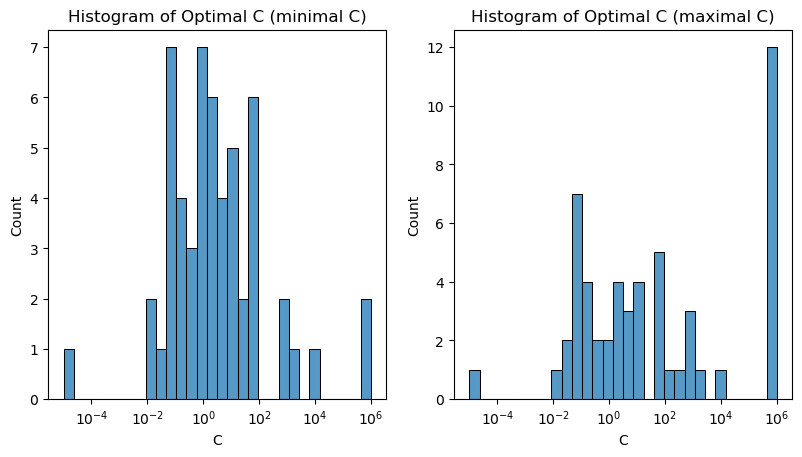

In [8]:
fig, axes = plt.subplots(ncols=2, figsize=(6.4 * 1.5, 4.8))
for i, df_tmp in enumerate([df_min_log_loss_min_C, df_min_log_loss_max_C]):
    g = sns.histplot(
        data=df_tmp,
        x="C",
        log_scale=True,
        bins=30,
        ax=axes[i],
)
    g.set(title=f"Histogram of Optimal C ({["minimal", "maximal"][i]} C)")

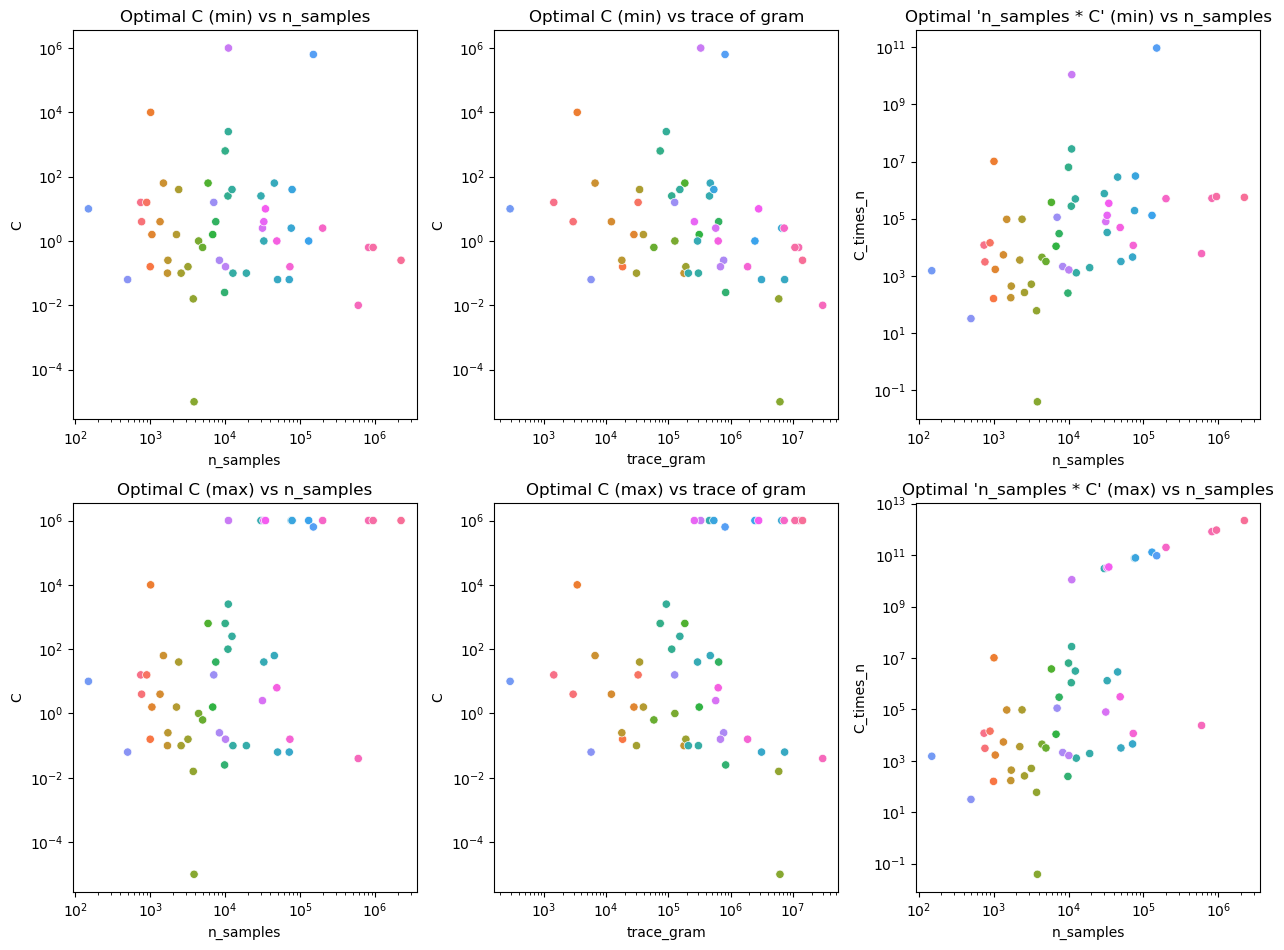

In [9]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(6.4 * 2, 4.8 * 2))
params = dict(hue="dataset", legend=False)
for i, df_tmp in enumerate([df_min_log_loss_min_C, df_min_log_loss_max_C]):
    minmax = ["min", "max"][i]
    sns.scatterplot(
        data=df_tmp,
        x="n_samples",
        y="C",
        **params,
        ax=axes[i, 0],
    )
    axes[i, 0].set(title=f"Optimal C ({minmax}) vs n_samples", xscale="log", yscale="log")
    sns.scatterplot(
        data=df_tmp,
        x="trace_gram",
        y="C",
        **params,
        ax=axes[i, 1],
    )
    axes[i, 1].set(title=f"Optimal C ({minmax}) vs trace of gram", xscale="log", yscale="log")
    sns.scatterplot(
        data=df_tmp.with_columns(C_times_n=pl.col("C") * pl.col("n_samples")),
        x="n_samples",
        y="C_times_n",
        **params,
        ax=axes[i, 2],
    )
    axes[i, 2].set(title=f"Optimal 'n_samples * C' ({minmax}) vs n_samples", xscale="log", yscale="log")
fig.tight_layout()

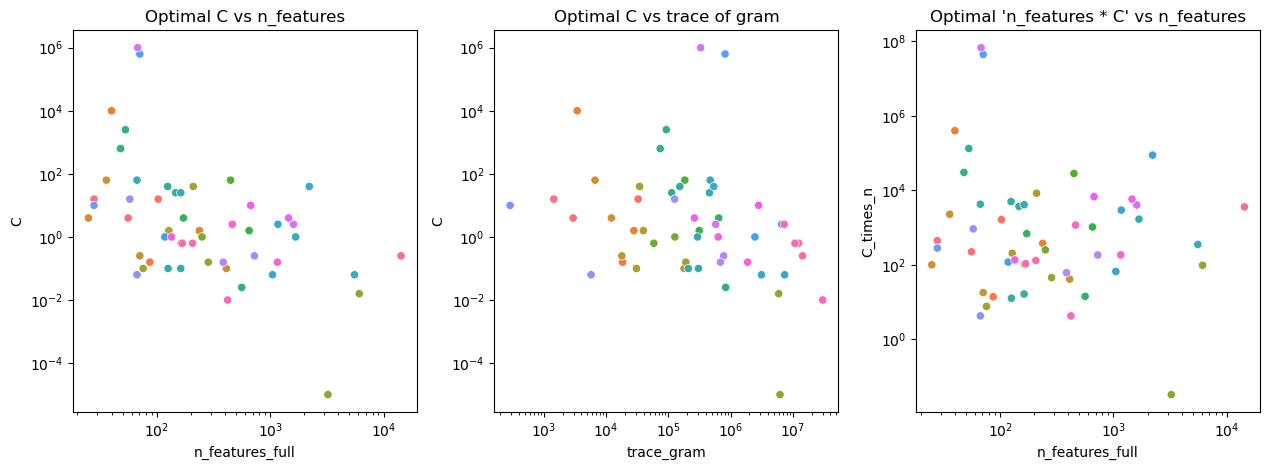

In [10]:
fig, axes = plt.subplots(ncols=3, figsize=(6.4 * 2, 4.8))
params = dict(hue="dataset", legend=False)
sns.scatterplot(
    data=df_min_log_loss_min_C,
    x="n_features_full",
    y="C",
    **params,
    ax=axes[0],
)
axes[0].set(title="Optimal C vs n_features", xscale="log", yscale="log")
sns.scatterplot(
    data=df_min_log_loss_min_C,
    x="trace_gram",
    y="C",
    **params,
    ax=axes[1],
)
axes[1].set(title="Optimal C vs trace of gram", xscale="log", yscale="log")
sns.scatterplot(
    data=df_min_log_loss_min_C.with_columns(C_times_n=pl.col("C") * pl.col("n_features_full")),
    x="n_features_full",
    y="C_times_n",
    **params,
    ax=axes[2],
)
axes[2].set(title="Optimal 'n_features * C' vs n_features", xscale="log", yscale="log")
fig.tight_layout()

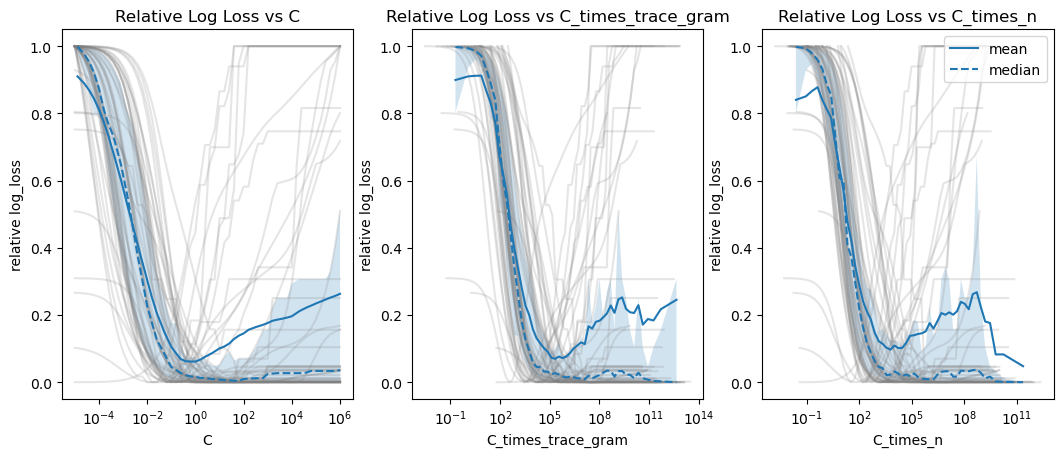

In [11]:
df_plot = df.with_columns(
    log_loss=(pl.col("log_loss") - pl.min("log_loss").over("dataset")) / (pl.max("log_loss").over("dataset") - pl.min("log_loss").over("dataset")) + 1e-6,
    C_times_trace_gram=pl.col("C") * pl.col("trace_gram"),
    C_times_n=pl.col("C") * pl.col("n_samples"),
)

fig, axes = plt.subplots(ncols=3, figsize=(6.4 * 2, 4.8))
for i, x in enumerate(["C", "C_times_trace_gram", "C_times_n"]):
    g = sns.lineplot(
        data=df_plot, x=x, y="log_loss", units="dataset", estimator=None, color="grey", alpha=0.2,
        legend=False, ax=axes[i]
    )
    g.set(ylabel="relative log_loss", xscale="log", title=f"Relative Log Loss vs {x}") #, ylim=(0, 0.2))

    df_mean = df_plot.with_columns(
        bins=pl.col(x).qcut(50)
    ).group_by("bins").agg(
        pl.col(x).mean(),
        pl.mean("log_loss"),
        pl.median("log_loss").alias("q50"),
        pl.col("log_loss").quantile(0.25).alias("q25"),
        pl.col("log_loss").quantile(0.75).alias("q75"),
    ).sort(x)
    axes[i].plot(df_mean[x], df_mean["log_loss"], label="mean")
    axes[i].plot(df_mean[x], df_mean["q50"], color="C0", linestyle="dashed", label="median")
    axes[i].fill_between(df_mean[x], df_mean["q25"], df_mean["q75"], alpha=0.2)
    if i == 2:
        axes[i].legend(loc="upper right")

## Run with raw numerical features / without B-Splines
This time, we do not preprocess numerical features, except for imputing missing values. Note that some datasets of this benchmark have convergence issues.
### Run Benchmark

In [3]:
%%time
# results = [run_single_benchmark(x, verbose=1) for x in DATA_INFOS.keys()]

# Save results on the way.
results = []
from pathlib import Path
file = Path("logistic_regression_optimal_penalty_raw_numerical.csv")
for x in DATA_INFOS.keys():
    run = run_single_benchmark(x, use_splines=False, verbose=1)
    results.append(run)
    df = pl.DataFrame([item for item in run])
    if file.exists():
        df_old = pl.read_csv(file)
        df = pl.concat([df, df_old])  # new on top
    df.write_csv(file)

running benchmark for blood-transfusion-service-center
  fetching and loading blood-transfusion-service-center dataset from openml
  n_samples=748 n_features=4 n_classes=2 n_features_full=4
    7.2 seconds for estimator.fit with solver newton-cholesky
running benchmark for diabetes
  fetching and loading diabetes dataset from openml
  n_samples=768 n_features=8 n_classes=2 n_features_full=8
    3.3 seconds for estimator.fit with solver newton-cholesky
running benchmark for anneal
  fetching and loading anneal dataset from openml
  n_samples=898 n_features=38 n_classes=5 n_features_full=85
    5.1 seconds for estimator.fit with solver newton-cholesky
running benchmark for credit-g
  fetching and loading credit-g dataset from openml
  n_samples=1000 n_features=20 n_classes=2 n_features_full=69
   0.44 seconds for estimator.fit with solver newton-cholesky
running benchmark for maternal_health_risk
  fetching and loading maternal_health_risk dataset from openml
  n_samples=1014 n_features=

/Users/lorentzen/github/scikit-learn/sklearn/linear_model/_glm/_newton_solver.py:199: ConvergenceWarning: lbfgs failed to converge after 98 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=98).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.iteration += _check_optimize_result("lbfgs", opt_res, max_iter=max_iter)
/Users/lorentzen/github/scikit-learn/sklearn/linear_model/_glm/_newton_solver.py:199: ConvergenceWarning: lbfgs failed to converge after 99 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=99).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.iteration += _check_optimize_result("lbfgs", opt_res, max_iter=max_iter)


    1.3 seconds for estimator.fit with solver newton-cholesky
running benchmark for taiwanese_bankruptcy_prediction
  fetching and loading taiwanese_bankruptcy_prediction dataset from openml
  n_samples=6819 n_features=94 n_classes=2 n_features_full=95


/Users/lorentzen/github/scikit-learn/sklearn/linear_model/_glm/_newton_solver.py:199: ConvergenceWarning: lbfgs failed to converge after 99 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=99).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.iteration += _check_optimize_result("lbfgs", opt_res, max_iter=max_iter)
/Users/lorentzen/github/scikit-learn/sklearn/linear_model/_glm/_newton_solver.py:199: ConvergenceWarning: lbfgs failed to converge after 99 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=99).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.iteration += _check_optimize_result("lbfgs", opt_res, max_iter=max_iter)
/Users/lorentzen/github/scikit-learn/skl

      8 seconds for estimator.fit with solver newton-cholesky
running benchmark for NATICUSdroid
  fetching and loading NATICUSdroid dataset from openml
  n_samples=7491 n_features=86 n_classes=2 n_features_full=172
    3.5 seconds for estimator.fit with solver newton-cg
running benchmark for coil2000_insurance_policies
  fetching and loading coil2000_insurance_policies dataset from openml
  n_samples=9822 n_features=85 n_classes=2 n_features_full=562
    3.8 seconds for estimator.fit with solver newton-cg
running benchmark for Bank_Customer_Churn
  fetching and loading Bank_Customer_Churn dataset from openml
  n_samples=10000 n_features=10 n_classes=2 n_features_full=18
   0.94 seconds for estimator.fit with solver newton-cholesky
running benchmark for heloc
  fetching and loading heloc dataset from openml
  n_samples=10000 n_features=10 n_classes=2 n_features_full=18
   0.87 seconds for estimator.fit with solver newton-cholesky
running benchmark for jm1
  fetching and loading jm1 dat

...

  2.4e+04 seconds for estimator.fit with solver newton-cg
running benchmark for SDSS17
  fetching and loading SDSS17 dataset from openml
  n_samples=78053 n_features=11 n_classes=3 n_features_full=2165
  1.1e+02 seconds for estimator.fit with solver newton-cg
running benchmark for customer_satisfaction_in_airline
  fetching and loading customer_satisfaction_in_airline dataset from openml
  n_samples=129880 n_features=21 n_classes=2 n_features_full=94
     32 seconds for estimator.fit with solver newton-cholesky
running benchmark for GiveMeSomeCredit
  fetching and loading GiveMeSomeCredit dataset from openml
  n_samples=150000 n_features=10 n_classes=2 n_features_full=17
    6.9 seconds for estimator.fit with solver newton-cholesky
running benchmark for iris
  fetching and loading iris dataset from openml
  n_samples=150 n_features=4 n_classes=3 n_features_full=4
   0.28 seconds for estimator.fit with solver newton-cholesky
running benchmark for dresses_sales
  fetching and loading dre

/usr/local/Caskroom/miniconda/base/envs/sklearn-dev/lib/python3.13/site-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/Users/lorentzen/github/scikit-learn/sklearn/utils/optimize.py:160: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/Caskroom/miniconda/base/envs/sklearn-dev/lib/python3.13/site-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/Users/lorentzen/github/scikit-learn/sklearn/utils/optimize.py:160: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/Caskroom/miniconda/base/envs/sklearn-dev/lib/python3.13/site-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_st

     18 seconds for estimator.fit with solver newton-cg
running benchmark for kicks
  fetching and loading kicks dataset from openml
  n_samples=72983 n_features=32 n_classes=2 n_features_full=1087


/usr/local/Caskroom/miniconda/base/envs/sklearn-dev/lib/python3.13/site-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/Users/lorentzen/github/scikit-learn/sklearn/utils/optimize.py:160: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/Caskroom/miniconda/base/envs/sklearn-dev/lib/python3.13/site-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_star, phi_star, old_fval, derphi_star = scalar_search_wolfe2(
/Users/lorentzen/github/scikit-learn/sklearn/utils/optimize.py:160: LineSearchWarning: The line search algorithm did not converge
  ret = line_search_wolfe2(
/usr/local/Caskroom/miniconda/base/envs/sklearn-dev/lib/python3.13/site-packages/scipy/optimize/_linesearch.py:312: LineSearchWarning: The line search algorithm did not converge
  alpha_st

  2.4e+02 seconds for estimator.fit with solver newton-cg
running benchmark for census_income_kdd
  fetching and loading census_income_kdd dataset from openml
  n_samples=199523 n_features=41 n_classes=2 n_features_full=410
  2.5e+02 seconds for estimator.fit with solver newton-cg
running benchmark for porto_seguro
  fetching and loading porto_seguro dataset from openml
  n_samples=595212 n_features=57 n_classes=2 n_features_full=350
  1.4e+02 seconds for estimator.fit with solver newton-cg
running benchmark for ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014
  fetching and loading ATLAS-Higgs-Boson-Machine-Learning-Challenge-2014 dataset from openml
  n_samples=818238 n_features=30 n_classes=2 n_features_full=33
     52 seconds for estimator.fit with solver newton-cholesky
running benchmark for Higgs-LeoGrin
  fetching and loading Higgs-LeoGrin dataset from openml
  n_samples=940160 n_features=24 n_classes=2 n_features_full=24
     51 seconds for estimator.fit with solver newton-cho

In [4]:
df = pl.DataFrame([item for run in results for item in run])
# df = pl.read_csv("logistic_regression_optimal_penalty_raw_numerical.csv")

In [ ]:
# df.write_parquet("logistic_regression_optimal_penalty_raw_numerical.parquet")

In [12]:
df = pl.read_parquet("logistic_regression_optimal_penalty_raw_numerical.parquet")

In [13]:
df.filter(pl.col("log_loss") == pl.min("log_loss").over("dataset"))

dataset,data_id,n_samples,n_features,n_classes,n_splits,C,log_loss,log_loss_std,n_features_full,trace_gram,fit_time,solver
str,i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,str
"""sf-police-incidents""",42732,2215023,8,2,5,0.015849,0.360003,0.001052,14249,3.6862e10,177.514642,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,0.025119,0.360003,0.001052,14249,3.6862e10,177.514642,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,0.039811,0.360003,0.001052,14249,3.6862e10,177.514642,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,0.063096,0.360003,0.001052,14249,3.6862e10,177.514642,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,0.1,0.360003,0.001052,14249,3.6862e10,177.514642,"""newton-cg"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""maternal_health_risk""",46941,1014,6,3,5,0.398107,0.783099,0.025341,10,2.6302e7,0.36138,"""newton-cholesky"""
"""credit-g""",46918,1000,20,2,5,0.158489,0.490707,0.041717,69,1.8663e10,0.444761,"""newton-cholesky"""
"""anneal""",46906,898,38,5,5,6.309573,0.073382,0.038502,85,5.2688e9,5.082905,"""newton-cholesky"""


Note that some datasets have minimal log loss for several values of `C`. So we need to be careful and select the smallest `C` (strongest regularization) among the `C` with minimal log loss.

In [14]:
df_min_log_loss_min_C = df.filter(
    pl.col("log_loss") == pl.min("log_loss").over("dataset")  # minimum log loss
).filter(
    pl.col("C") == pl.min("C").over("dataset")  # mininum C -> strongest penalty
)

df_min_log_loss_max_C = df.filter(
    pl.col("log_loss") == pl.min("log_loss").over("dataset")  # minimum log loss
).filter(
    pl.col("C") == pl.max("C").over("dataset")  # maximum C -> smallest penalty
)

df_min_log_loss_min_C

dataset,data_id,n_samples,n_features,n_classes,n_splits,C,log_loss,log_loss_std,n_features_full,trace_gram,fit_time,solver
str,i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,str
"""sf-police-incidents""",42732,2215023,8,2,5,0.015849,0.360003,0.001052,14249,3.6862e10,177.514642,"""newton-cg"""
"""Higgs-LeoGrin""",44129,940160,24,2,5,3.981072,0.640598,0.00051,24,2.5601e7,50.958775,"""newton-cholesky"""
"""ATLAS-Higgs-Boson-Machine-Lear…",45550,818238,30,2,5,0.251189,0.495459,0.001853,33,2.0536e11,52.154738,"""newton-cholesky"""
"""porto_seguro""",42742,595212,57,2,5,0.01,0.152446,0.000639,350,2.0229e8,144.697235,"""newton-cg"""
"""census_income_kdd""",42750,199523,41,2,5,0.630957,0.12516,0.001903,410,6.0667e12,249.500711,"""newton-cg"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""maternal_health_risk""",46941,1014,6,3,5,0.398107,0.783099,0.025341,10,2.6302e7,0.36138,"""newton-cholesky"""
"""credit-g""",46918,1000,20,2,5,0.158489,0.490707,0.041717,69,1.8663e10,0.444761,"""newton-cholesky"""
"""anneal""",46906,898,38,5,5,6.309573,0.073382,0.038502,85,5.2688e9,5.082905,"""newton-cholesky"""


In [15]:
df.group_by("dataset").agg(pl.col("fit_time").max()).top_k(5, by="fit_time")

dataset,fit_time
str,f64
"""APSFailure""",23739.993426
"""kddcup09_appetency""",11228.586679
"""census_income_kdd""",249.500711
"""kicks""",238.39259
"""sf-police-incidents""",177.514642


In [16]:
df["dataset"].n_unique()

54

### Visualization

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

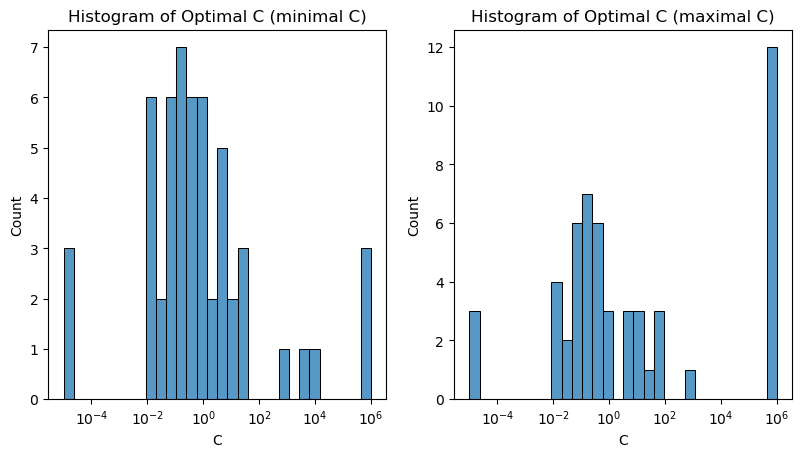

In [18]:
fig, axes = plt.subplots(ncols=2, figsize=(6.4 * 1.5, 4.8))
for i, df_tmp in enumerate([df_min_log_loss_min_C, df_min_log_loss_max_C]):
    g = sns.histplot(
        data=df_tmp,
        x="C",
        log_scale=True,
        bins=30,
        ax=axes[i],
)
    g.set(title=f"Histogram of Optimal C ({["minimal", "maximal"][i]} C)")

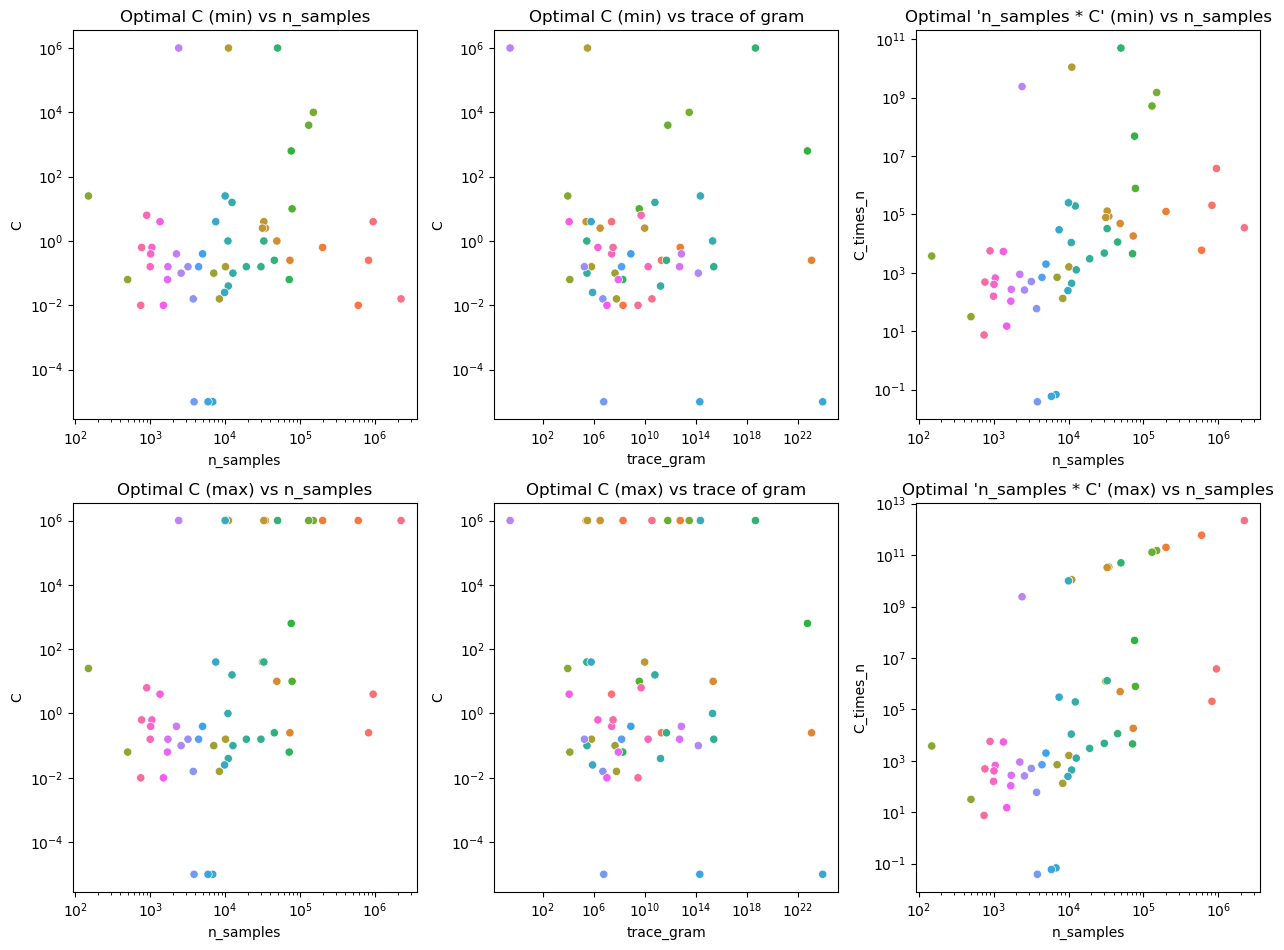

In [19]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(6.4 * 2, 4.8 * 2))
params = dict(hue="dataset", legend=False)
for i, df_tmp in enumerate([df_min_log_loss_min_C, df_min_log_loss_max_C]):
    minmax = ["min", "max"][i]
    sns.scatterplot(
        data=df_tmp,
        x="n_samples",
        y="C",
        **params,
        ax=axes[i, 0],
    )
    axes[i, 0].set(title=f"Optimal C ({minmax}) vs n_samples", xscale="log", yscale="log")
    sns.scatterplot(
        data=df_tmp,
        x="trace_gram",
        y="C",
        **params,
        ax=axes[i, 1],
    )
    axes[i, 1].set(title=f"Optimal C ({minmax}) vs trace of gram", xscale="log", yscale="log")
    sns.scatterplot(
        data=df_tmp.with_columns(C_times_n=pl.col("C") * pl.col("n_samples")),
        x="n_samples",
        y="C_times_n",
        **params,
        ax=axes[i, 2],
    )
    axes[i, 2].set(title=f"Optimal 'n_samples * C' ({minmax}) vs n_samples", xscale="log", yscale="log")
fig.tight_layout()

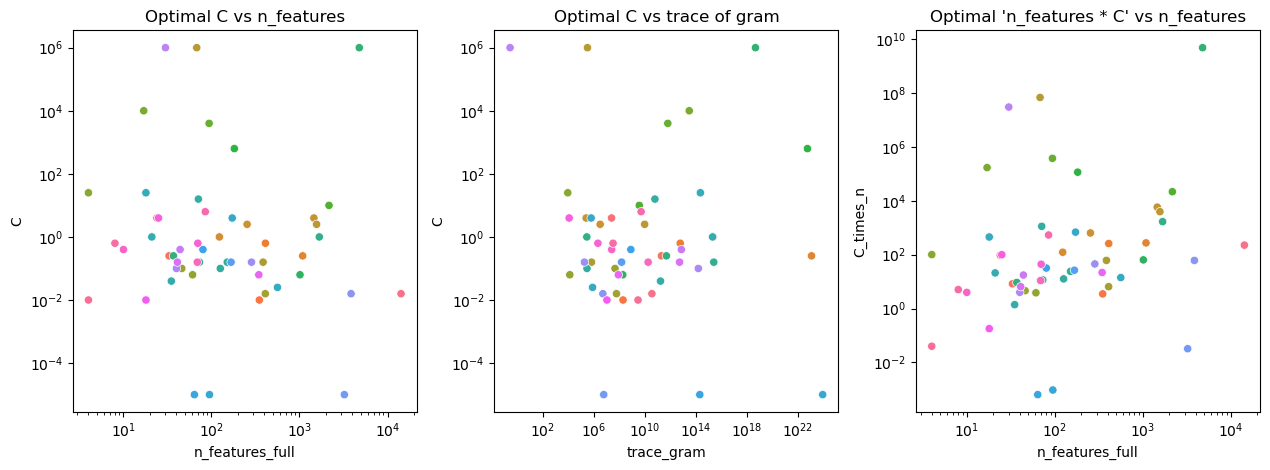

In [20]:
fig, axes = plt.subplots(ncols=3, figsize=(6.4 * 2, 4.8))
params = dict(hue="dataset", legend=False)
sns.scatterplot(
    data=df_min_log_loss_min_C,
    x="n_features_full",
    y="C",
    **params,
    ax=axes[0],
)
axes[0].set(title="Optimal C vs n_features", xscale="log", yscale="log")
sns.scatterplot(
    data=df_min_log_loss_min_C,
    x="trace_gram",
    y="C",
    **params,
    ax=axes[1],
)
axes[1].set(title="Optimal C vs trace of gram", xscale="log", yscale="log")
sns.scatterplot(
    data=df_min_log_loss_min_C.with_columns(C_times_n=pl.col("C") * pl.col("n_features_full")),
    x="n_features_full",
    y="C_times_n",
    **params,
    ax=axes[2],
)
axes[2].set(title="Optimal 'n_features * C' vs n_features", xscale="log", yscale="log")
fig.tight_layout()

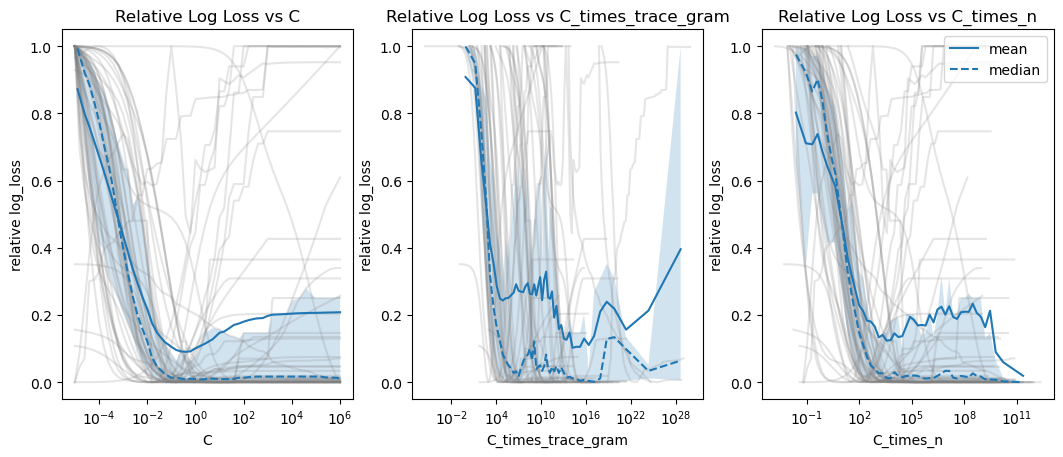

In [21]:
df_plot = df.with_columns(
    log_loss=(pl.col("log_loss") - pl.min("log_loss").over("dataset")) / (pl.max("log_loss").over("dataset") - pl.min("log_loss").over("dataset")) + 1e-6,
    C_times_trace_gram=pl.col("C") * pl.col("trace_gram"),
    C_times_n=pl.col("C") * pl.col("n_samples"),
)

fig, axes = plt.subplots(ncols=3, figsize=(6.4 * 2, 4.8))
for i, x in enumerate(["C", "C_times_trace_gram", "C_times_n"]):
    g = sns.lineplot(
        data=df_plot, x=x, y="log_loss", units="dataset", estimator=None, color="grey", alpha=0.2,
        legend=False, ax=axes[i]
    )
    g.set(ylabel="relative log_loss", xscale="log", title=f"Relative Log Loss vs {x}") #, ylim=(0, 0.2))

    df_mean = df_plot.with_columns(
        bins=pl.col(x).qcut(50)
    ).group_by("bins").agg(
        pl.col(x).mean(),
        pl.mean("log_loss"),
        pl.median("log_loss").alias("q50"),
        pl.col("log_loss").quantile(0.25).alias("q25"),
        pl.col("log_loss").quantile(0.75).alias("q75"),
    ).sort(x)
    axes[i].plot(df_mean[x], df_mean["log_loss"], label="mean")
    axes[i].plot(df_mean[x], df_mean["q50"], color="C0", linestyle="dashed", label="median")
    axes[i].fill_between(df_mean[x], df_mean["q25"], df_mean["q75"], alpha=0.2)
    if i == 2:
        axes[i].legend(loc="upper right")

### Plot Gaël's results
In https://github.com/GaelVaroquaux/sklearn_logreg_regularization, Gaël run with a slightly extendet set of datasets, with raw numerical features as above.

In [22]:
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

# Source: https://github.com/GaelVaroquaux/sklearn_logreg_regularization/blob/main/logistic_regression_default.parquet
df = pl.read_parquet("https://github.com/GaelVaroquaux/sklearn_logreg_regularization/raw/refs/heads/main/logistic_regression_paths.parquet")

In [25]:
df["dataset"].n_unique()

55

In [26]:
df.filter(pl.col("log_loss") == pl.min("log_loss").over("dataset"))

dataset,data_id,n_samples,n_features,n_classes,n_splits,C,log_loss,log_loss_std,n_features_full,trace_gram,fit_time,solver
str,i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,str
"""blood-transfusion-service-cent…",46913,748,4,2,5,0.007758,0.477291,0.020778,4,3.0152e9,25.18683,"""newton-cholesky"""
"""diabetes""",46921,768,8,2,5,0.539863,0.484852,0.03819,8,3.3369e7,7.870479,"""newton-cholesky"""
"""anneal""",46906,898,38,5,5,7.215521,0.073226,0.039467,85,5.2688e9,11.239291,"""newton-cholesky"""
"""credit-g""",46918,1000,20,2,5,0.131253,0.490524,0.039487,69,1.8663e10,8.160094,"""newton-cholesky"""
"""maternal_health_risk""",46941,1014,6,3,5,0.336945,0.783082,0.02486,10,2.6302e7,8.075194,"""newton-cholesky"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""sf-police-incidents""",42732,2215023,8,2,5,4.9308e6,0.359132,0.00322,14249,3.6862e10,730.605694,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,6.2413e6,0.359132,0.00322,14249,3.6862e10,730.605694,"""newton-cg"""
"""sf-police-incidents""",42732,2215023,8,2,5,7.9002e6,0.359132,0.00322,14249,3.6862e10,730.605694,"""newton-cg"""


In [27]:
df_min_log_loss_min_C = df.filter(
    pl.col("log_loss") == pl.min("log_loss").over("dataset")  # minimum log loss
).filter(
    pl.col("C") == pl.min("C").over("dataset")  # mininum C -> strongest penalty
)

df_min_log_loss_max_C = df.filter(
    pl.col("log_loss") == pl.min("log_loss").over("dataset")  # minimum log loss
).filter(
    pl.col("C") == pl.max("C").over("dataset")  # maximum C -> smallest penalty
)

df_min_log_loss_min_C

dataset,data_id,n_samples,n_features,n_classes,n_splits,C,log_loss,log_loss_std,n_features_full,trace_gram,fit_time,solver
str,i64,i64,i64,i64,i64,f64,f64,f64,i64,f64,f64,str
"""blood-transfusion-service-cent…",46913,748,4,2,5,0.007758,0.477291,0.020778,4,3.0152e9,25.18683,"""newton-cholesky"""
"""diabetes""",46921,768,8,2,5,0.539863,0.484852,0.03819,8,3.3369e7,7.870479,"""newton-cholesky"""
"""anneal""",46906,898,38,5,5,7.215521,0.073226,0.039467,85,5.2688e9,11.239291,"""newton-cholesky"""
"""credit-g""",46918,1000,20,2,5,0.131253,0.490524,0.039487,69,1.8663e10,8.160094,"""newton-cholesky"""
"""maternal_health_risk""",46941,1014,6,3,5,0.336945,0.783082,0.02486,10,2.6302e7,8.075194,"""newton-cholesky"""
…,…,…,…,…,…,…,…,…,…,…,…,…
"""porto_seguro""",42742,595212,57,2,5,0.01243,0.152441,0.000636,350,2.0229e8,287.753936,"""newton-cg"""
"""ATLAS-Higgs-Boson-Machine-Lear…",45550,818238,30,2,5,0.266193,0.495459,0.001853,33,2.0536e11,215.896011,"""newton-cholesky"""
"""Higgs-LeoGrin""",44129,940160,24,2,5,4.503429,0.640598,0.00051,24,2.5601e7,197.361601,"""newton-cholesky"""


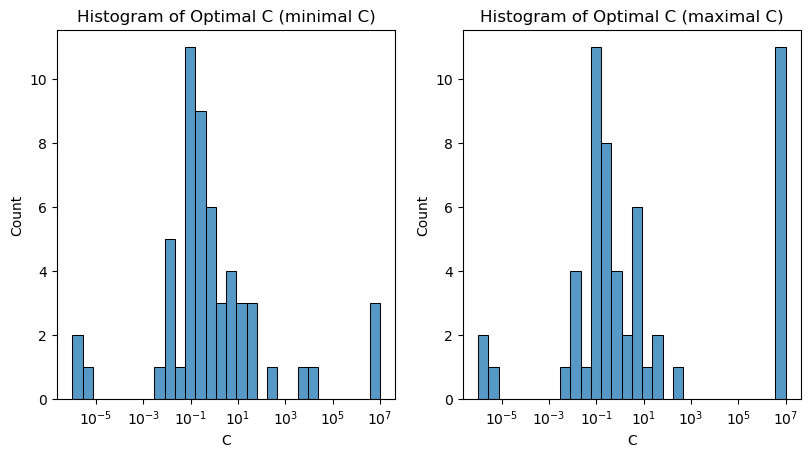

In [28]:
fig, axes = plt.subplots(ncols=2, figsize=(6.4 * 1.5, 4.8))
for i, df_tmp in enumerate([df_min_log_loss_min_C, df_min_log_loss_max_C]):
    g = sns.histplot(
        data=df_tmp,
        x="C",
        log_scale=True,
        bins=30,
        ax=axes[i],
)
    g.set(title=f"Histogram of Optimal C ({["minimal", "maximal"][i]} C)")

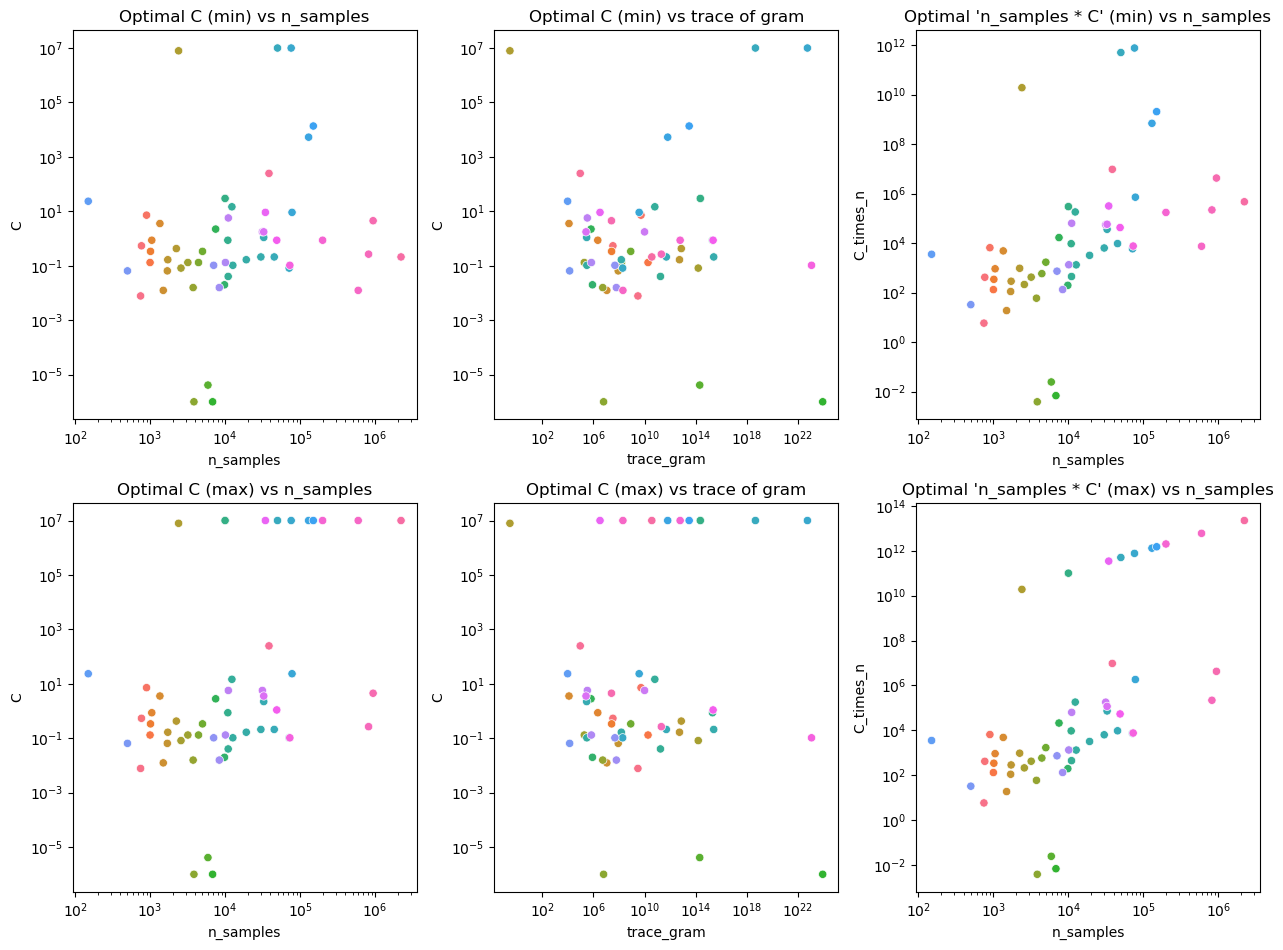

In [29]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(6.4 * 2, 4.8 * 2))
params = dict(hue="dataset", legend=False)
for i, df_tmp in enumerate([df_min_log_loss_min_C, df_min_log_loss_max_C]):
    minmax = ["min", "max"][i]
    sns.scatterplot(
        data=df_tmp,
        x="n_samples",
        y="C",
        **params,
        ax=axes[i, 0],
    )
    axes[i, 0].set(title=f"Optimal C ({minmax}) vs n_samples", xscale="log", yscale="log")
    sns.scatterplot(
        data=df_tmp,
        x="trace_gram",
        y="C",
        **params,
        ax=axes[i, 1],
    )
    axes[i, 1].set(title=f"Optimal C ({minmax}) vs trace of gram", xscale="log", yscale="log")
    sns.scatterplot(
        data=df_tmp.with_columns(C_times_n=pl.col("C") * pl.col("n_samples")),
        x="n_samples",
        y="C_times_n",
        **params,
        ax=axes[i, 2],
    )
    axes[i, 2].set(title=f"Optimal 'n_samples * C' ({minmax}) vs n_samples", xscale="log", yscale="log")
fig.tight_layout()

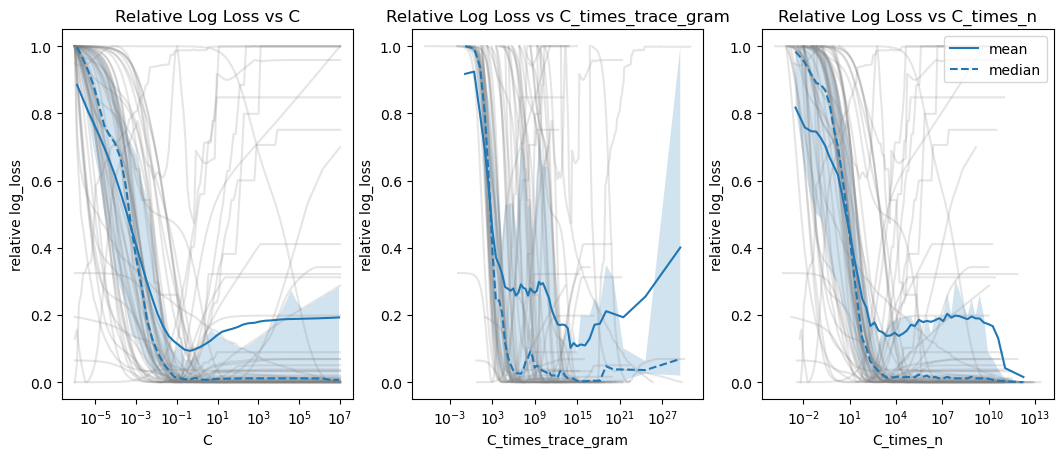

In [30]:
df_plot = df.with_columns(
    log_loss=(pl.col("log_loss") - pl.min("log_loss").over("dataset")) / (pl.max("log_loss").over("dataset") - pl.min("log_loss").over("dataset")) + 1e-6,
    C_times_trace_gram=pl.col("C") * pl.col("trace_gram"),
    C_times_n=pl.col("C") * pl.col("n_samples"),
)

fig, axes = plt.subplots(ncols=3, figsize=(6.4 * 2, 4.8))
for i, x in enumerate(["C", "C_times_trace_gram", "C_times_n"]):
    g = sns.lineplot(
        data=df_plot, x=x, y="log_loss", units="dataset", estimator=None, color="grey", alpha=0.2,
        legend=False, ax=axes[i]
    )
    g.set(ylabel="relative log_loss", xscale="log", title=f"Relative Log Loss vs {x}") #, ylim=(0, 0.2))

    df_mean = df_plot.with_columns(
        bins=pl.col(x).qcut(50)
    ).group_by("bins").agg(
        pl.col(x).mean(),
        pl.mean("log_loss"),
        pl.median("log_loss").alias("q50"),
        pl.col("log_loss").quantile(0.25).alias("q25"),
        pl.col("log_loss").quantile(0.75).alias("q75"),
    ).sort(x)
    axes[i].plot(df_mean[x], df_mean["log_loss"], label="mean")
    axes[i].plot(df_mean[x], df_mean["q50"], color="C0", linestyle="dashed", label="median")
    axes[i].fill_between(df_mean[x], df_mean["q25"], df_mean["q75"], alpha=0.2)
    if i == 2:
        axes[i].legend(loc="upper right")
